In [29]:
import pandas as pd
import numpy as np

In [30]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_clean = df_usa_agr.drop(['Year','Soil Health Index','Irrigation Access %', 'Total Precipitation (mm)'], axis=1)
df_usa_agr_numeric = df_usa_agr_clean.select_dtypes(include="number")
df_usa_agr_numeric.head()

,Average Temperature (C),CO2 Emissions (MT),Crop Yield (MT per HA),Extreme Weather Events,Pesticide Use (KG per HA),Fertilizer Use (KG per HA),Economic Impact (Million USD)
8968,17.19,10.73,2.180,5,26.06,71.56,353.16
8969,14.70,11.45,2.500,9,19.48,46.13,1126.27
8970,12.03,3.86,2.450,8,13.10,2.56,1026.35
8971,12.18,19.10,1.872,8,43.15,22.46,925.79
8972,30.62,29.28,3.249,9,5.80,49.85,509.77


In [31]:
y = df_usa_agr_numeric["Crop Yield (MT per HA)"]
X = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)"])

In [32]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()
clean_numeric_dfCO2.head()

,gdp,co2_growth_prct,co2_per_capita,co2_per_gdp,temperature_change_from_co2
3644,4.641366e+11,8.263,16.236,0.599,0.008
3645,4.613021e+11,0.495,16.103,0.606,0.008
3646,4.786337e+11,1.788,16.208,0.594,0.008
3647,5.015248e+11,1.528,16.294,0.576,0.008
3648,5.279932e+11,1.674,16.405,0.556,0.008


In [33]:
y1 = clean_numeric_dfCO2["temperature_change_from_co2"]
X1 = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Standardize the predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean_numeric_dfCO2)

# Run DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# Add cluster labels to the original DataFrame
clean_numeric_dfCO2["Cluster"] = clusters

# Display the first few rows
print(clean_numeric_dfCO2.head())

# Count observations in each cluster
print(clean_numeric_dfCO2["Cluster"].value_counts().sort_index())

               gdp  co2_growth_prct  co2_per_capita  co2_per_gdp  \
3644  4.641366e+11            8.263          16.236        0.599   
3645  4.613021e+11            0.495          16.103        0.606   
3646  4.786337e+11            1.788          16.208        0.594   
3647  5.015248e+11            1.528          16.294        0.576   
3648  5.279932e+11            1.674          16.405        0.556   

      temperature_change_from_co2  Cluster  
3644                        0.008        0  
3645                        0.008        0  
3646                        0.008        0  
3647                        0.008        0  
3648                        0.008        0  
Cluster
-1      14
 0    1354
 1      33
 2       8
Name: count, dtype: int64


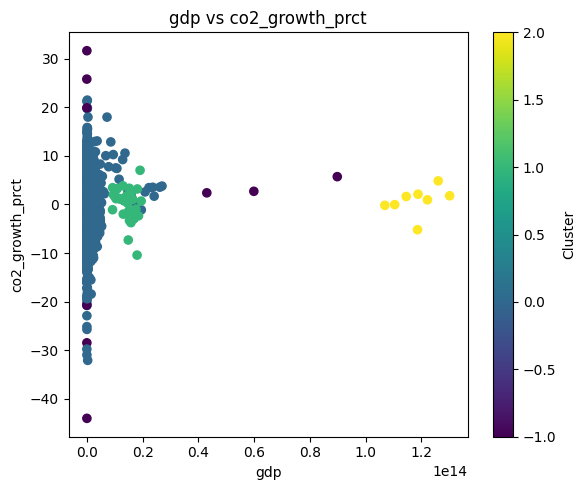

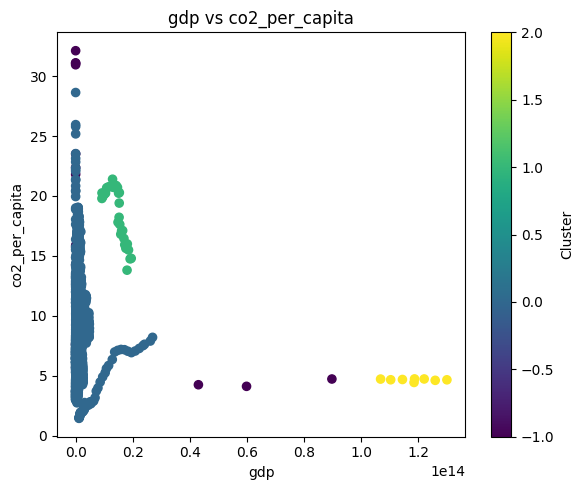

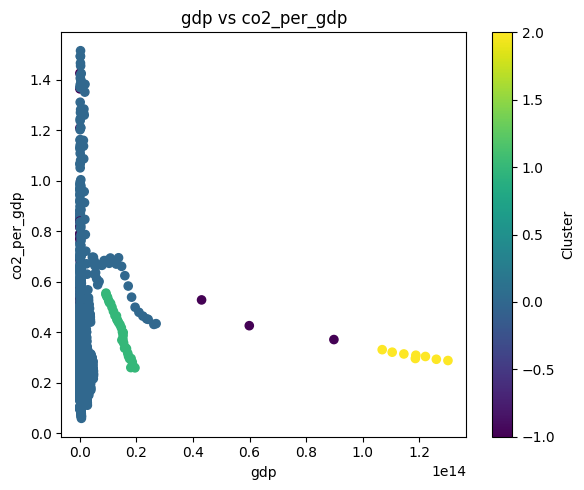

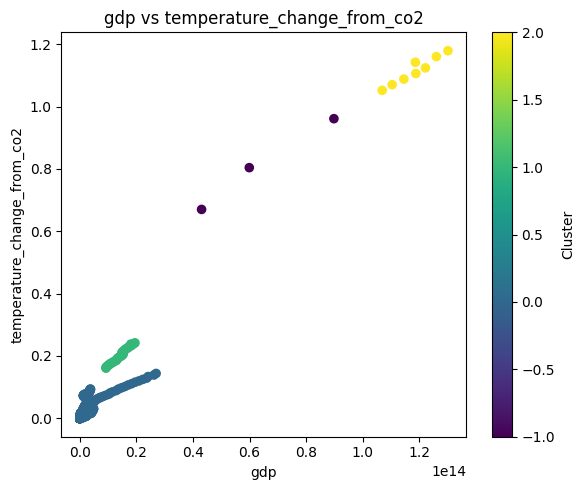

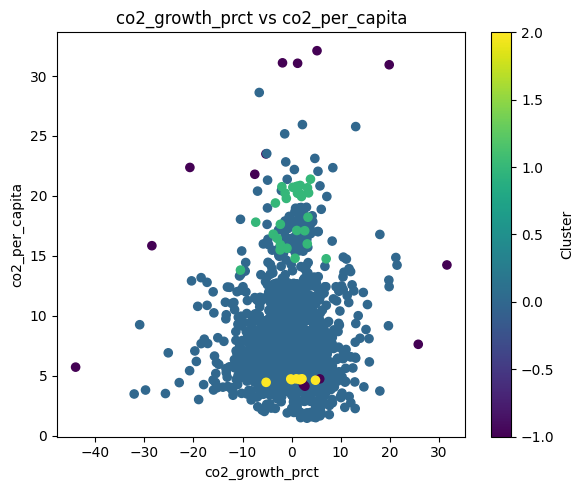

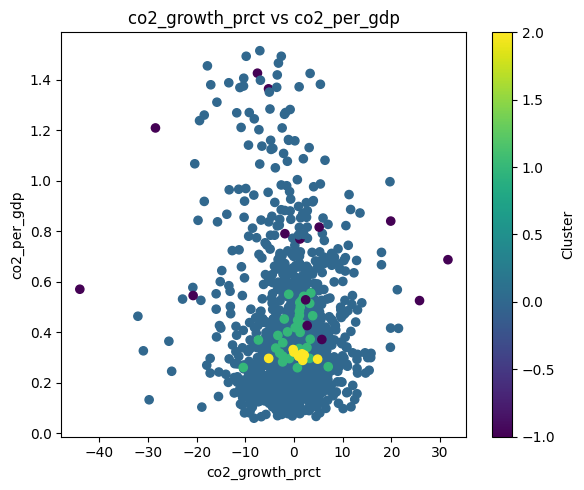

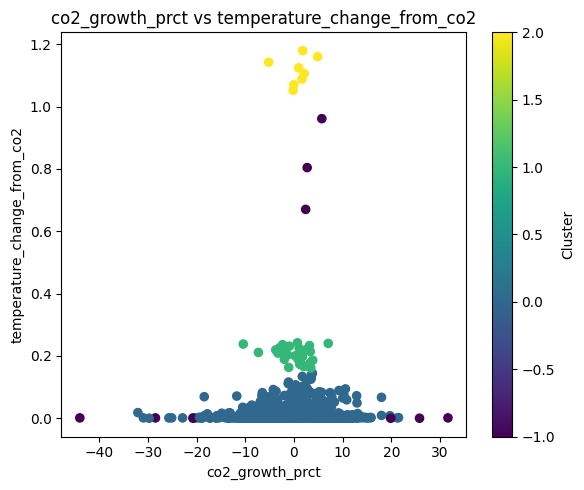

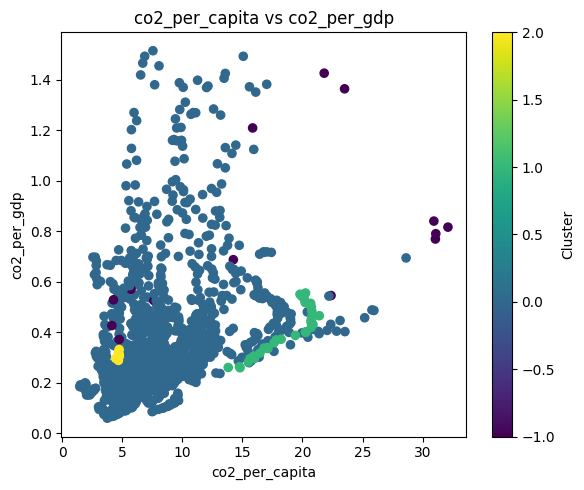

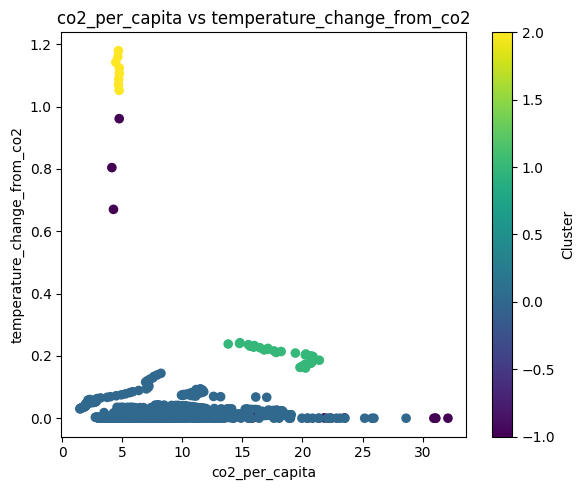

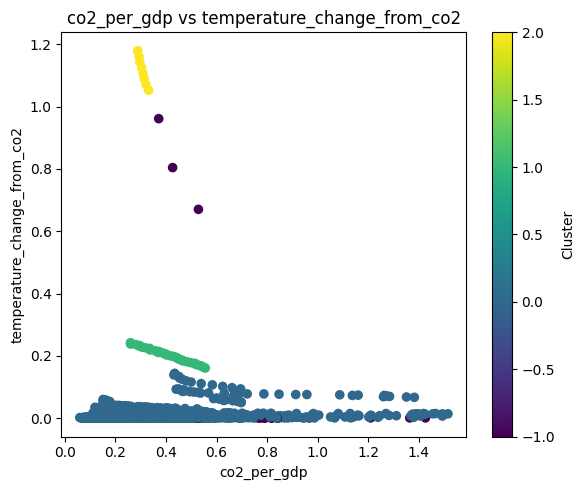

In [35]:
import itertools
import matplotlib.pyplot as plt

cols = clean_numeric_dfCO2.drop(columns=["Cluster"]).columns

for x_var, y_var in itertools.combinations(cols, 2):
    plt.figure(figsize=(6, 5))

    plt.scatter(
        clean_numeric_dfCO2[x_var],
        clean_numeric_dfCO2[y_var],
        c=clean_numeric_dfCO2["Cluster"],
        cmap="viridis",
        s=35
    )

    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.title(f"{x_var} vs {y_var}")
    plt.colorbar(label="Cluster")
    plt.tight_layout()
    plt.show()

In [36]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Standardize the predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_usa_agr_numeric)

# Run DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# Add cluster labels to the original DataFrame
df_usa_agr_numeric["Cluster"] = clusters

# Display the first few rows
print(df_usa_agr_numeric.head())

# Count observations in each cluster
print(df_usa_agr_numeric["Cluster"].value_counts().sort_index())

      Average Temperature (C)  CO2 Emissions (MT)  Crop Yield (MT per HA)  \
8968                    17.19               10.73                   2.180   
8969                    14.70               11.45                   2.500   
8970                    12.03                3.86                   2.450   
8971                    12.18               19.10                   1.872   
8972                    30.62               29.28                   3.249   

      Extreme Weather Events  Pesticide Use (KG per HA)  \
8968                       5                      26.06   
8969                       9                      19.48   
8970                       8                      13.10   
8971                       8                      43.15   
8972                       9                       5.80   

      Fertilizer Use (KG per HA)  Economic Impact (Million USD)  Cluster  
8968                       71.56                         353.16        0  
8969                       46.13

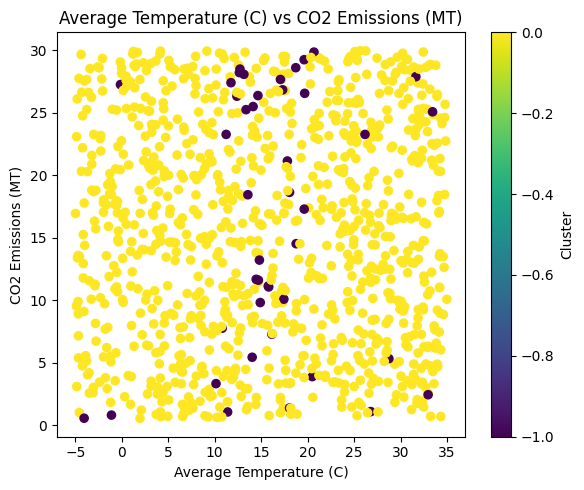

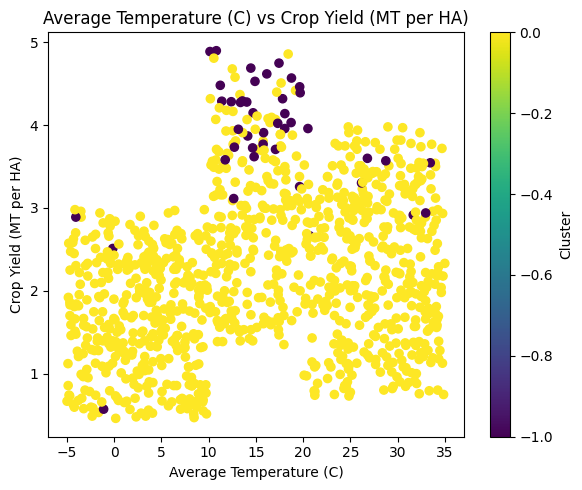

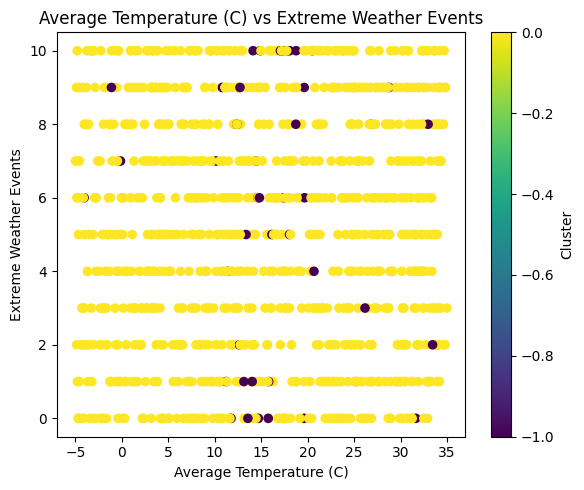

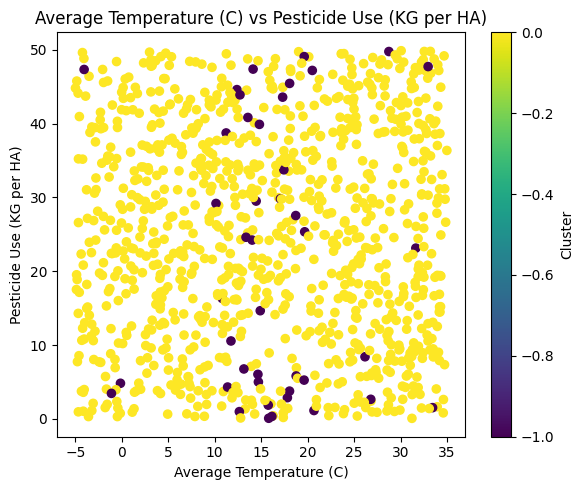

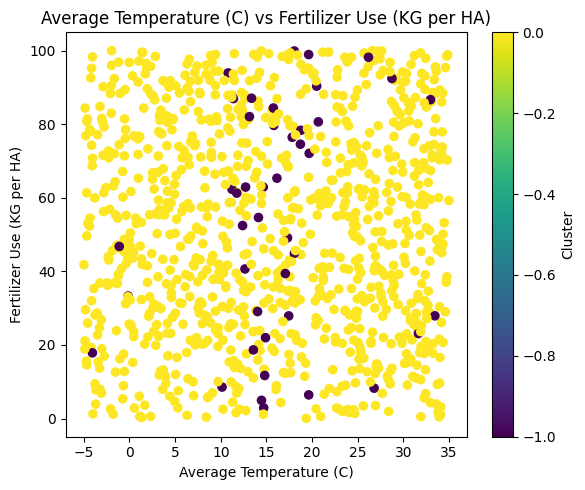

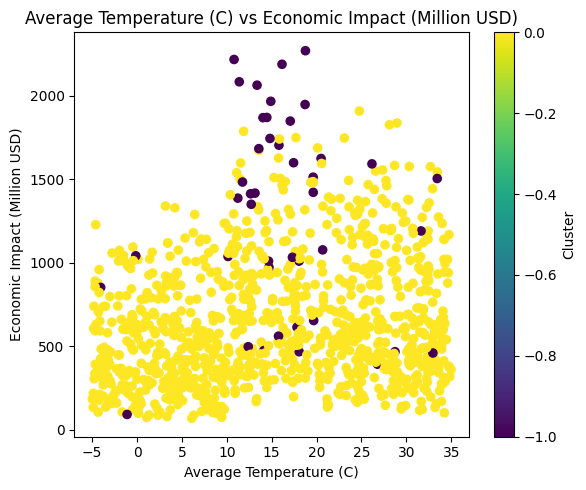

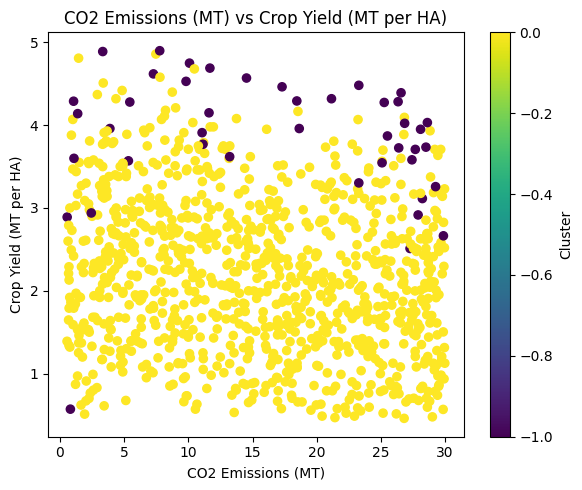

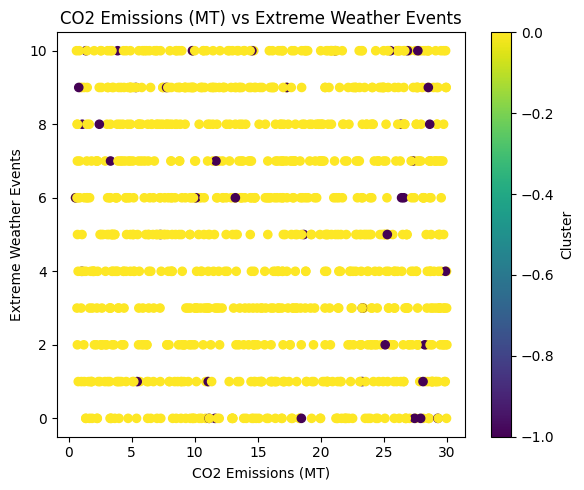

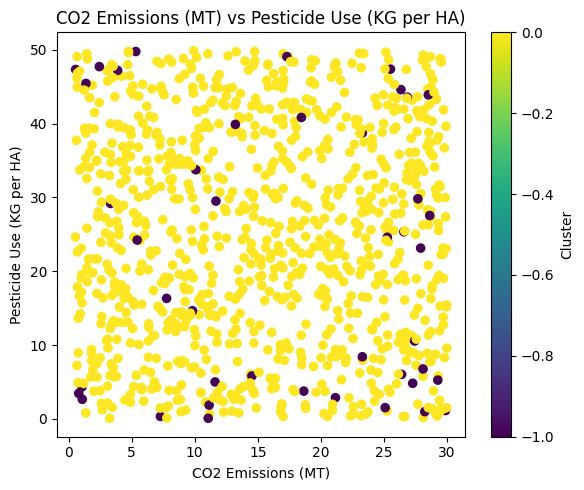

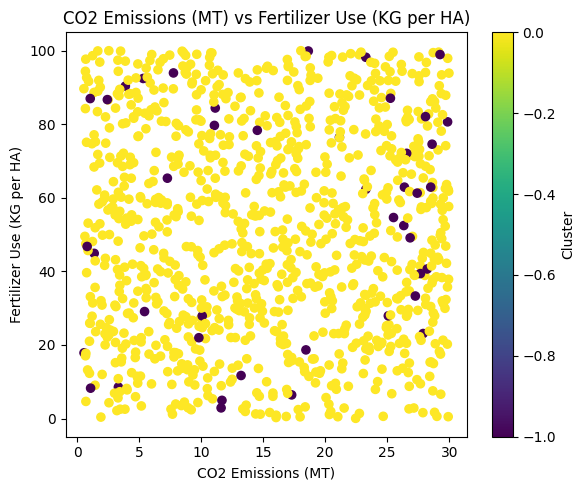

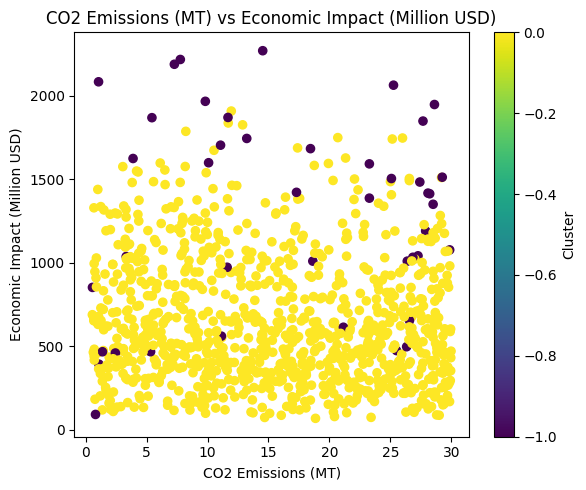

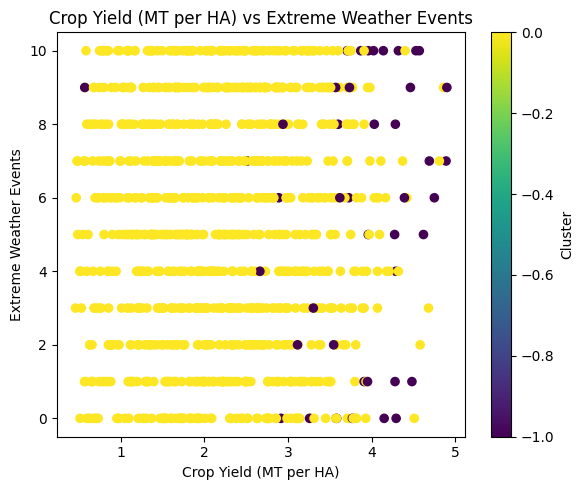

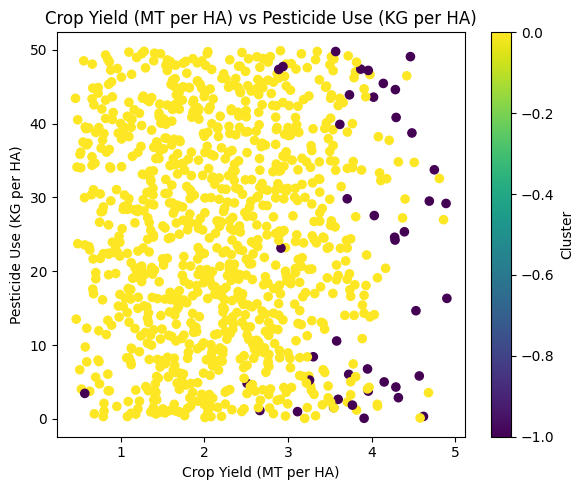

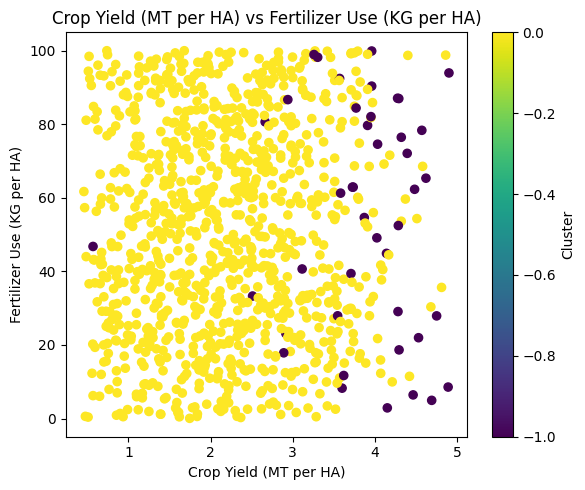

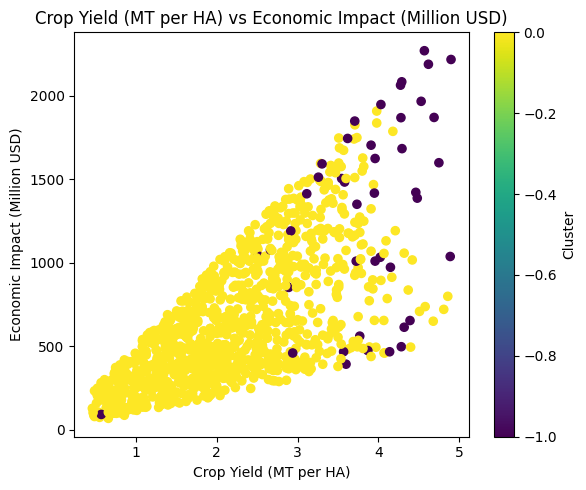

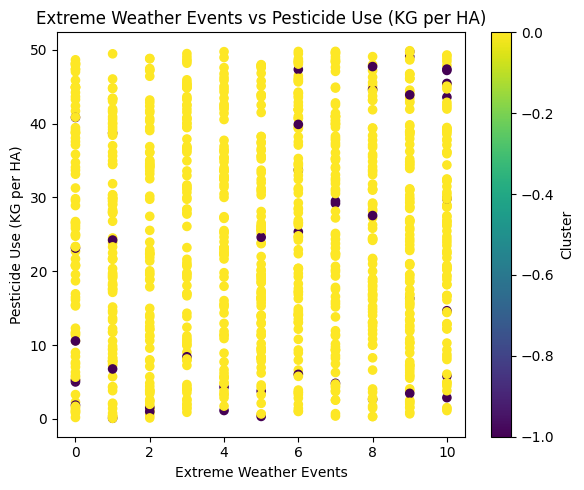

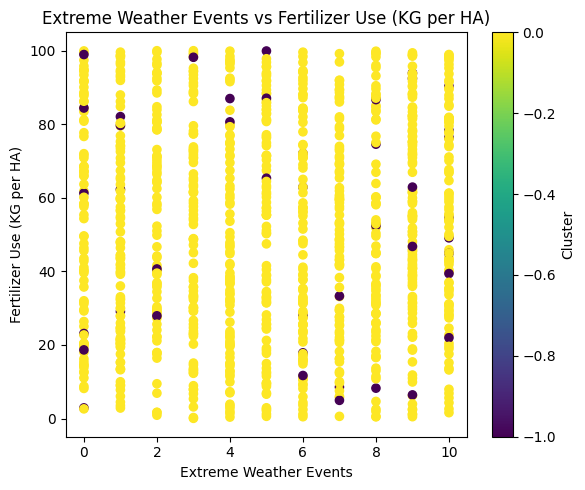

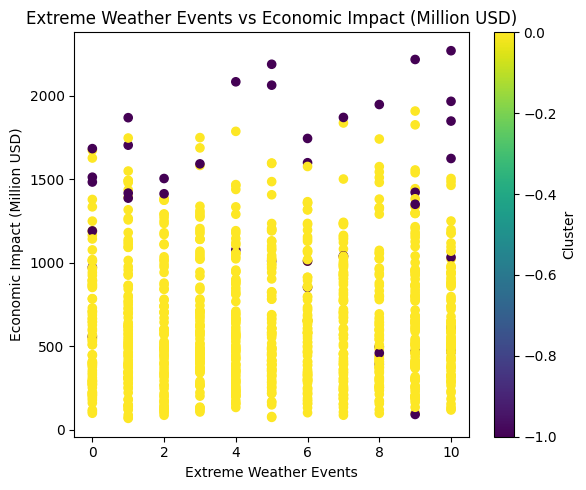

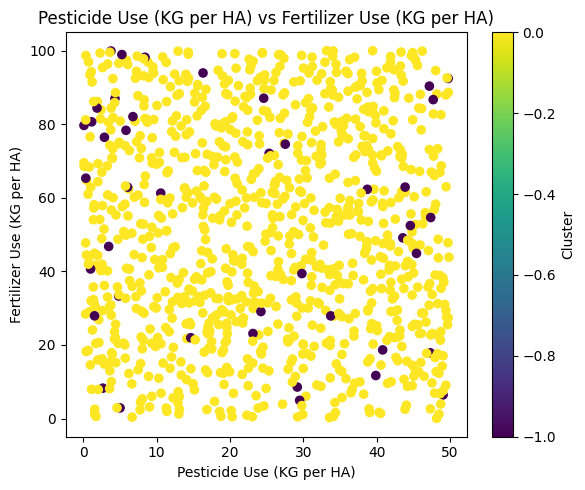

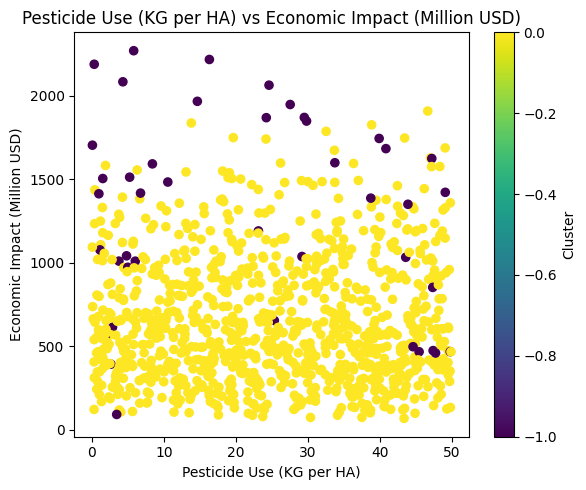

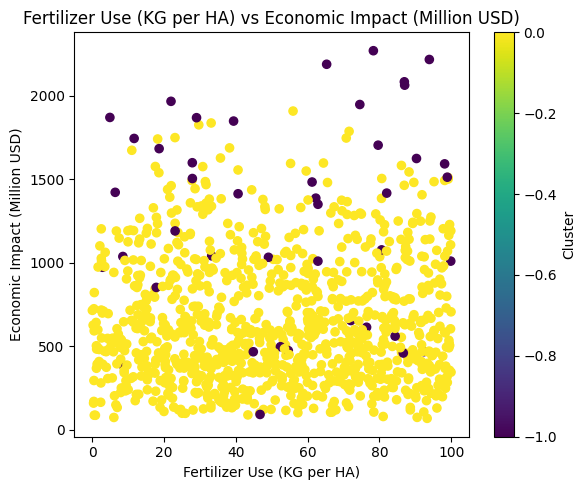

In [37]:
import itertools
import matplotlib.pyplot as plt

cols = df_usa_agr_numeric.drop(columns=["Cluster"]).columns

for x_var, y_var in itertools.combinations(cols, 2):
    plt.figure(figsize=(6, 5))

    plt.scatter(
        df_usa_agr_numeric[x_var],
        df_usa_agr_numeric[y_var],
        c=df_usa_agr_numeric["Cluster"],
        cmap="viridis",
        s=35
    )

    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.title(f"{x_var} vs {y_var}")
    plt.colorbar(label="Cluster")
    plt.tight_layout()
    plt.show()

In [38]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Target and predictors
y1 = clean_numeric_dfCO2["temperature_change_from_co2"]
X1 = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

# Standardize the predictors
scaler = StandardScaler()
X_scaled1 = scaler.fit_transform(X1)

# Fit Hierarchical Agglomerative Clustering
hac = AgglomerativeClustering(
    n_clusters=3,      # Change as desired
    metric="euclidean",
    linkage="ward"
)

clusters = hac.fit_predict(X_scaled1)

# Add cluster labels to the DataFrame
clean_numeric_dfCO2["HAC_Cluster"] = clusters

# View results
print(clean_numeric_dfCO2.head())
print(clean_numeric_dfCO2["HAC_Cluster"].value_counts().sort_index())

               gdp  co2_growth_prct  co2_per_capita  co2_per_gdp  \
3644  4.641366e+11            8.263          16.236        0.599   
3645  4.613021e+11            0.495          16.103        0.606   
3646  4.786337e+11            1.788          16.208        0.594   
3647  5.015248e+11            1.528          16.294        0.576   
3648  5.279932e+11            1.674          16.405        0.556   

      temperature_change_from_co2  Cluster  HAC_Cluster  
3644                        0.008        0            2  
3645                        0.008        0            0  
3646                        0.008        0            0  
3647                        0.008        0            0  
3648                        0.008        0            0  
HAC_Cluster
0     270
1       8
2    1131
Name: count, dtype: int64


In [39]:
for method in ["ward", "complete", "average", "single"]:
    hac = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )
    labels = hac.fit_predict(X_scaled1)
    print(method, pd.Series(labels).value_counts().to_dict())

ward {2: 1131, 0: 270, 1: 8}
complete {2: 1348, 0: 53, 1: 8}
average {0: 1398, 1: 8, 2: 3}
single {0: 1398, 1: 8, 2: 3}


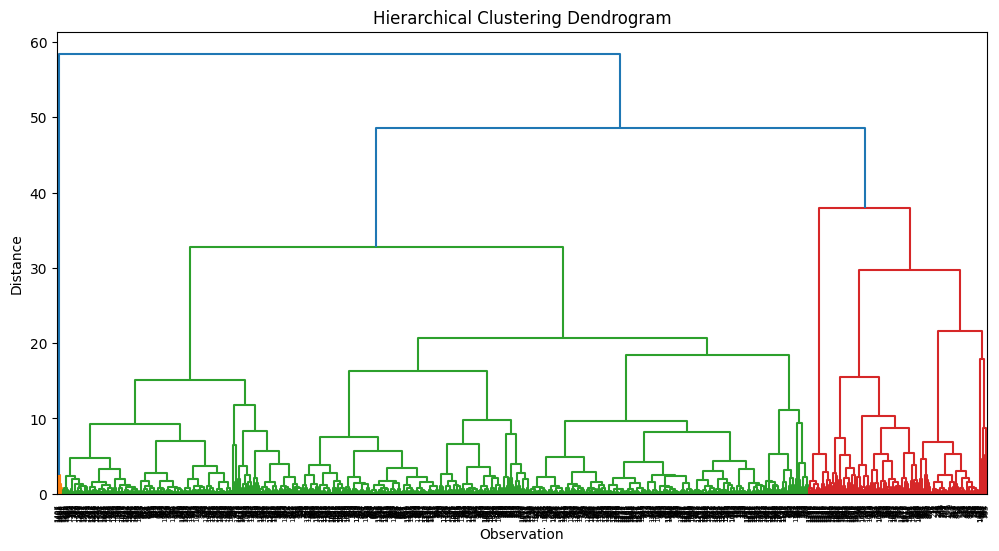

In [40]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute the linkage matrix
Z1 = linkage(X_scaled1, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z1)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observation")
plt.ylabel("Distance")
plt.show()

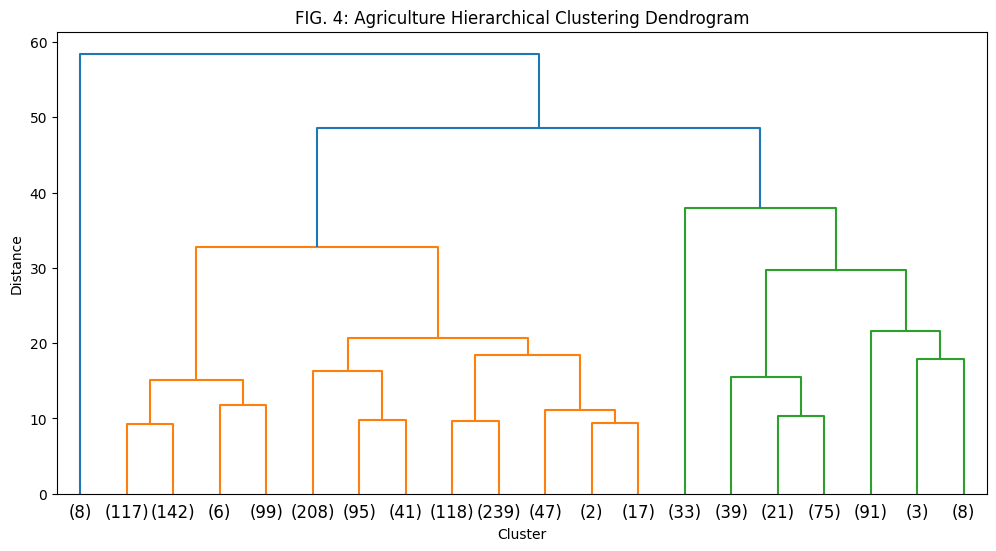

In [41]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z1,
    truncate_mode="lastp",
    p=20,              # show last 20 merged clusters
    show_leaf_counts=True
)

plt.title("FIG. 4: Agriculture Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

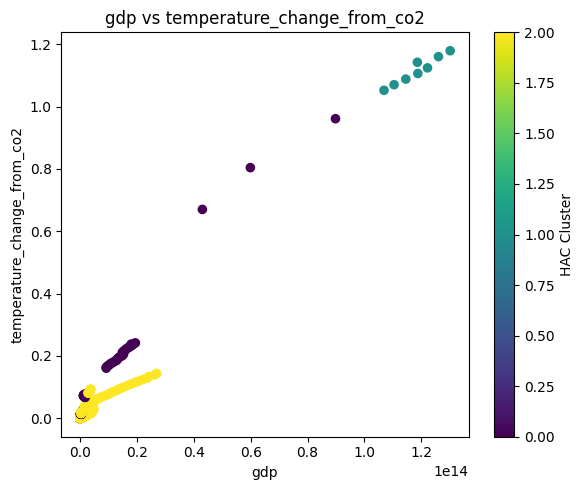

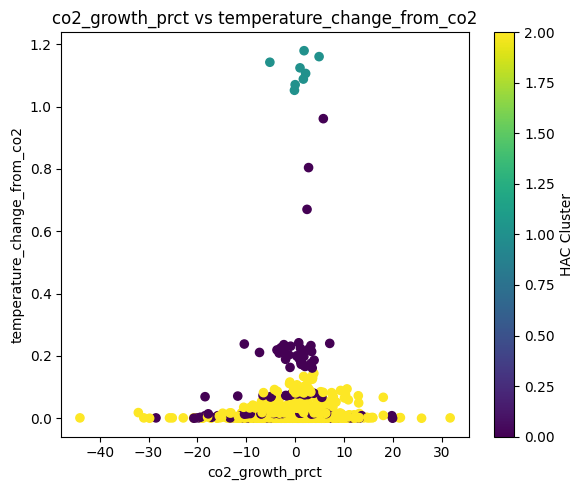

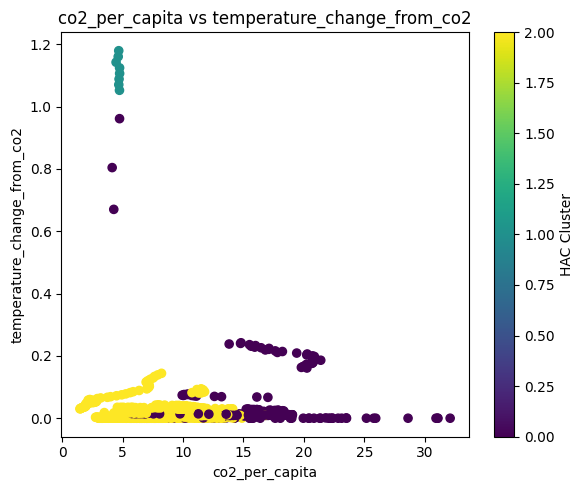

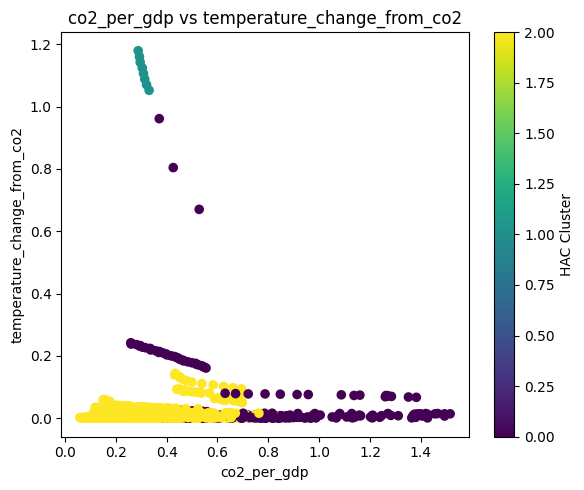

In [42]:
import matplotlib.pyplot as plt

target = "temperature_change_from_co2"

predictors = clean_numeric_dfCO2.drop(
    columns=[target, "Cluster", "HAC_Cluster"],
    errors="ignore"
).columns

for predictor in predictors:

    plt.figure(figsize=(6, 5))

    plt.scatter(
        clean_numeric_dfCO2[predictor],
        clean_numeric_dfCO2[target],
        c=clean_numeric_dfCO2["HAC_Cluster"],
        cmap="viridis",
        s=35
    )

    plt.xlabel(predictor)
    plt.ylabel(target)
    plt.title(f"{predictor} vs {target}")
    plt.colorbar(label="HAC Cluster")
    plt.tight_layout()
    plt.show()

In [43]:
dbscan.core_sample_indices_

array([   0,    1,    2,    3,    7,   10,   11,   12,   13,   14,   15,
         16,   17,   19,   21,   22,   23,   24,   25,   26,   27,   28,
         29,   31,   32,   33,   34,   35,   36,   37,   38,   39,   40,
         41,   42,   43,   44,   45,   46,   47,   48,   50,   51,   52,
         53,   55,   56,   57,   58,   59,   60,   61,   62,   63,   64,
         65,   67,   68,   69,   70,   71,   72,   75,   76,   78,   81,
         82,   83,   84,   85,   86,   87,   89,   91,   92,   93,   94,
         95,   96,   97,   98,   99,  101,  102,  103,  105,  109,  110,
        111,  113,  114,  115,  116,  117,  118,  121,  122,  124,  125,
        126,  127,  128,  130,  131,  132,  134,  135,  136,  137,  138,
        139,  140,  141,  143,  144,  145,  146,  147,  148,  152,  153,
        154,  155,  157,  158,  159,  160,  161,  162,  163,  164,  165,
        166,  167,  168,  169,  170,  172,  174,  175,  176,  179,  180,
        182,  183,  184,  185,  186,  187,  188,  1

In [44]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np

target = "temperature_change_from_co2"

X = clean_numeric_dfCO2.drop(
    columns=[target, "Cluster", "HAC_Cluster"],
    errors="ignore"
)

X_scaled = StandardScaler().fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

clean_numeric_dfCO2["DBSCAN_Cluster"] = dbscan_labels

In [45]:
clean_numeric_dfCO2["DBSCAN_Point_Type"] = "Border"

clean_numeric_dfCO2.loc[
    dbscan_labels == -1,
    "DBSCAN_Point_Type"
] = "Noise"

clean_numeric_dfCO2.iloc[
    dbscan.core_sample_indices_,
    clean_numeric_dfCO2.columns.get_loc("DBSCAN_Point_Type")
] = "Core"

In [46]:
clean_numeric_dfCO2["DBSCAN_Point_Type"] = "Border"

clean_numeric_dfCO2.loc[
    dbscan_labels == -1,
    "DBSCAN_Point_Type"
] = "Noise"

clean_numeric_dfCO2.iloc[
    dbscan.core_sample_indices_,
    clean_numeric_dfCO2.columns.get_loc("DBSCAN_Point_Type")
] = "Core"

clean_numeric_dfCO2["DBSCAN_Point_Type"].value_counts()

DBSCAN_Point_Type
Core      1173
Noise      172
Border      64
Name: count, dtype: int64

In [47]:
clean_numeric_dfCO2["DBSCAN_Point_Type"].value_counts()

DBSCAN_Point_Type
Core      1173
Noise      172
Border      64
Name: count, dtype: int64

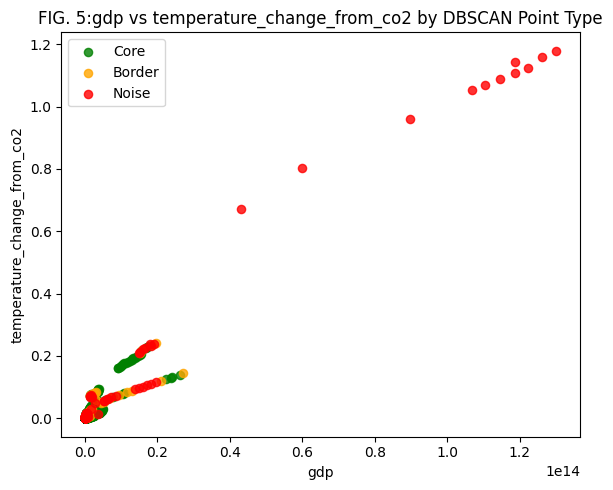

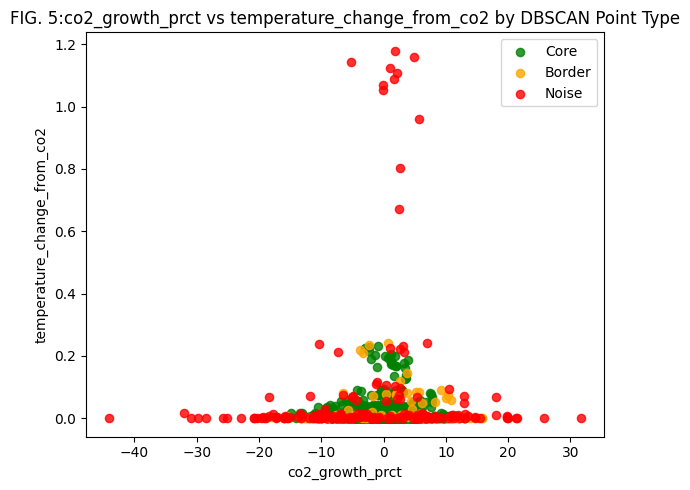

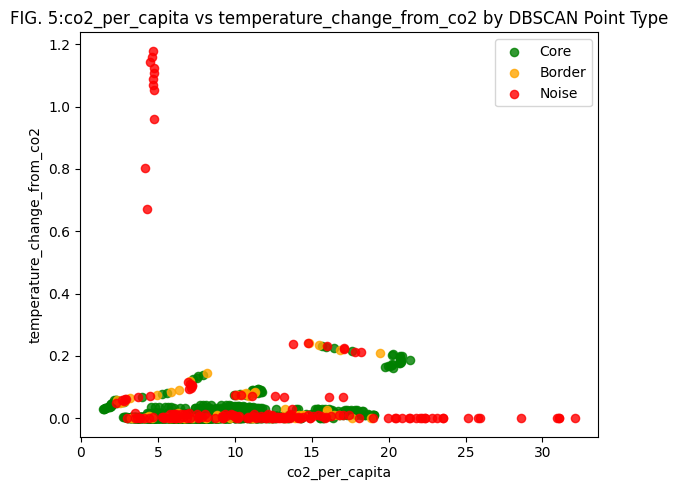

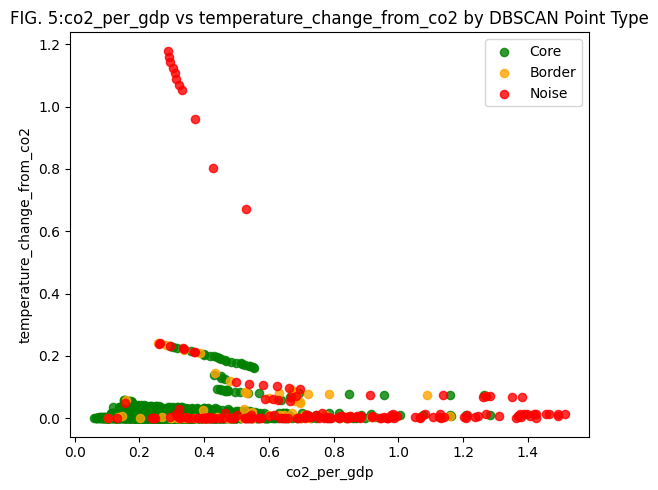

In [54]:
import matplotlib.pyplot as plt

target = "temperature_change_from_co2"

predictors = clean_numeric_dfCO2.drop(
    columns=[target, "Cluster", "HAC_Cluster", "DBSCAN_Cluster", "DBSCAN_Point_Type"],
    errors="ignore"
).columns

colors = {
    "Core": "green",
    "Border": "orange",
    "Noise": "red"
}

for predictor in predictors:

    plt.figure(figsize=(6, 5))

    for point_type, color in colors.items():
        subset = clean_numeric_dfCO2[
            clean_numeric_dfCO2["DBSCAN_Point_Type"] == point_type
        ]

        plt.scatter(
            subset[predictor],
            subset[target],
            label=point_type,
            color=color,
            s=35,
            alpha=0.8
        )

    plt.xlabel(predictor)
    plt.ylabel(target)
    plt.title(f"FIG. 5:{predictor} vs {target} by DBSCAN Point Type")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [49]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Target and predictors
y = df_usa_agr_numeric["Crop Yield (MT per HA)"]
X = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)"])

# Standardize the predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Hierarchical Agglomerative Clustering
hac = AgglomerativeClustering(
    n_clusters=3,      # Change as desired
    metric="euclidean",
    linkage="ward"
)

clusters = hac.fit_predict(X_scaled)

# Add cluster labels to the DataFrame
df_usa_agr_numeric["HAC_Cluster"] = clusters

# View results
print(df_usa_agr_numeric.head())
print(df_usa_agr_numeric["HAC_Cluster"].value_counts().sort_index())

      Average Temperature (C)  CO2 Emissions (MT)  Crop Yield (MT per HA)  \
8968                    17.19               10.73                   2.180   
8969                    14.70               11.45                   2.500   
8970                    12.03                3.86                   2.450   
8971                    12.18               19.10                   1.872   
8972                    30.62               29.28                   3.249   

      Extreme Weather Events  Pesticide Use (KG per HA)  \
8968                       5                      26.06   
8969                       9                      19.48   
8970                       8                      13.10   
8971                       8                      43.15   
8972                       9                       5.80   

      Fertilizer Use (KG per HA)  Economic Impact (Million USD)  Cluster  \
8968                       71.56                         353.16        0   
8969                       46.

In [50]:
for method in ["ward", "complete", "average", "single"]:
    hac = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )
    labels = hac.fit_predict(X_scaled)
    print(method, pd.Series(labels).value_counts().to_dict())

ward {0: 516, 2: 473, 1: 43}
complete {0: 584, 2: 405, 1: 43}
average {1: 989, 2: 31, 0: 12}
single {1: 989, 0: 42, 2: 1}


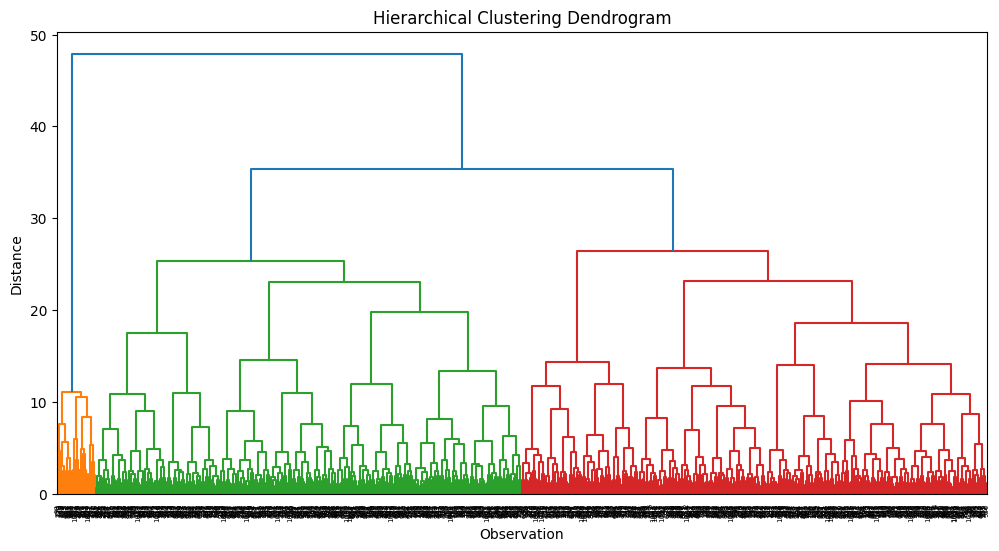

In [51]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute the linkage matrix
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observation")
plt.ylabel("Distance")
plt.show()

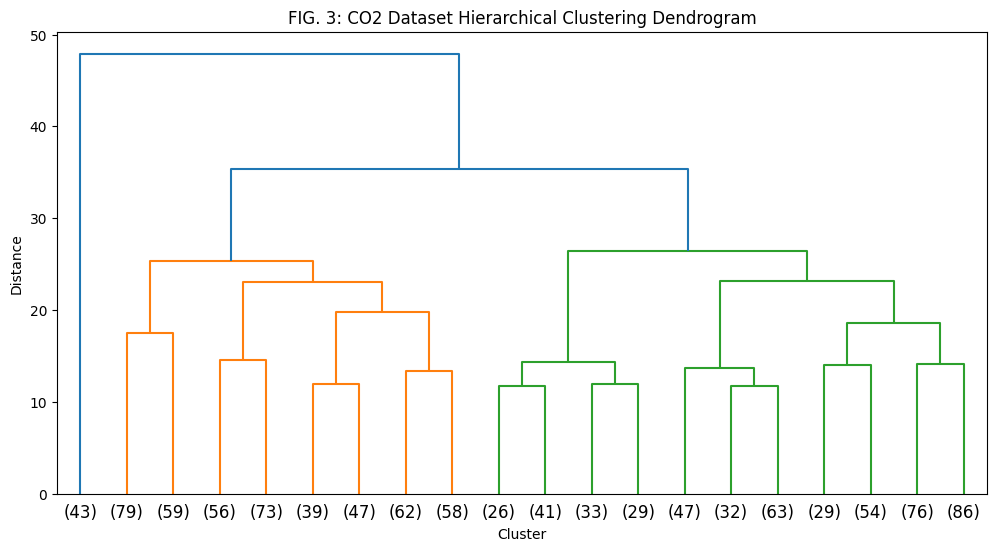

In [52]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,              # show last 20 merged clusters
    show_leaf_counts=True
)

plt.title("FIG. 3: CO2 Dataset Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

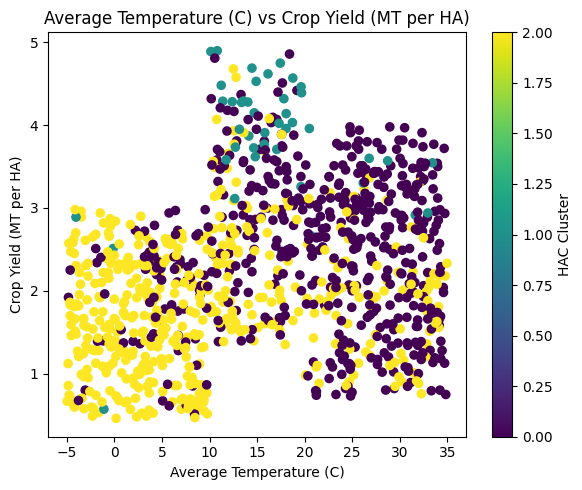

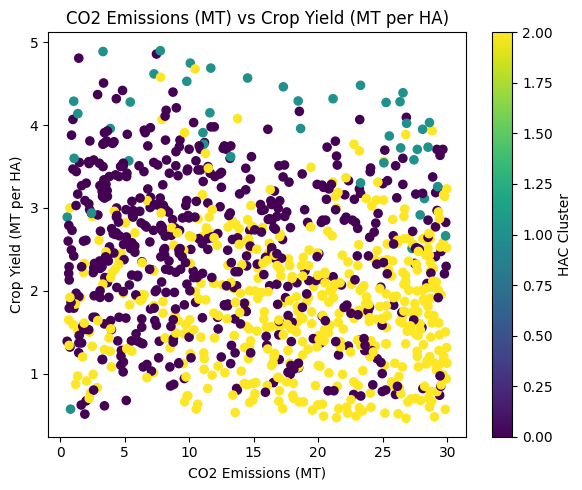

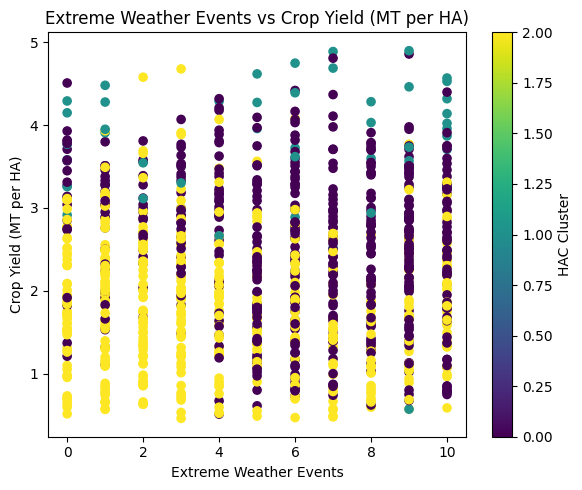

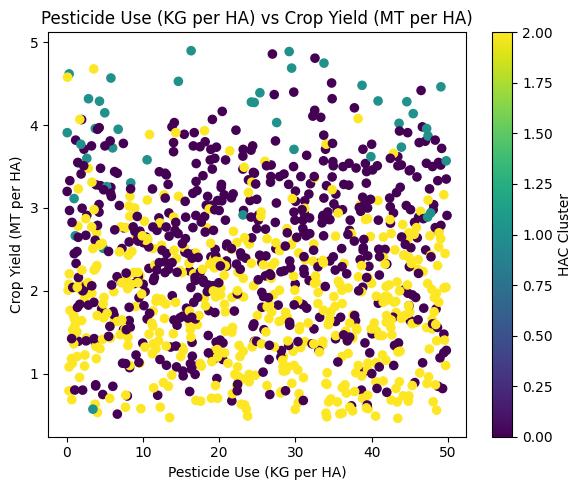

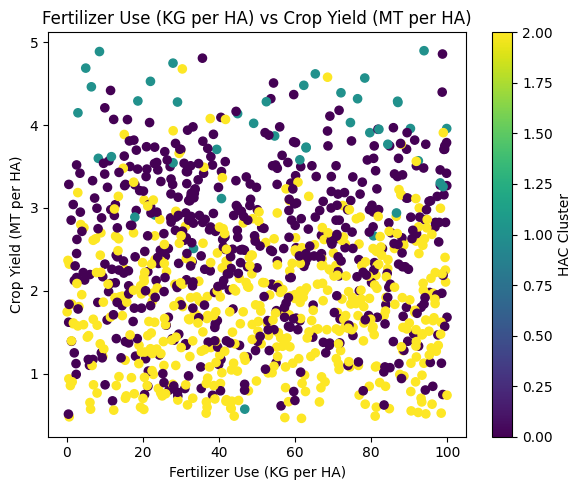

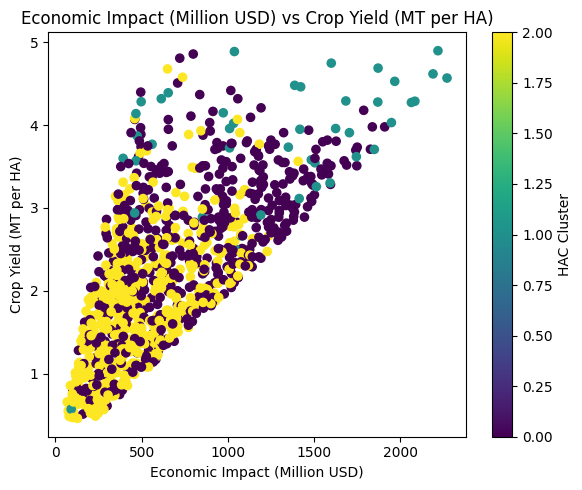

In [53]:
import matplotlib.pyplot as plt

target = "Crop Yield (MT per HA)"

predictors = df_usa_agr_numeric.drop(
    columns=[target, "Cluster", "HAC_Cluster"],
    errors="ignore"
).columns

for predictor in predictors:

    plt.figure(figsize=(6, 5))

    plt.scatter(
        df_usa_agr_numeric[predictor],
        df_usa_agr_numeric[target],
        c=df_usa_agr_numeric["HAC_Cluster"],
        cmap="viridis",
        s=35
    )

    plt.xlabel(predictor)
    plt.ylabel(target)
    plt.title(f"{predictor} vs {target}")
    plt.colorbar(label="HAC Cluster")
    plt.tight_layout()
    plt.show()